# EDA

In [57]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


path = kagglehub.dataset_download("yasserh/loan-default-dataset")
file_path = os.path.join(path, "Loan_Default.csv")
data = pd.read_csv(file_path)

In [58]:
cat_cols = [col for col in data.columns if data[col].dtype in ['object', 'category']]
num_cols = [col for col in data.columns if data[col].dtype in ['int64', 'float64']]

num_cols.remove('Status') 
num_cols.remove('ID') 
num_cols.remove('year') 

num_cols_with_target = num_cols.copy()
num_cols_with_target.append('Status')

### Analysis of numerical feature

 correlation matrix of numerical features

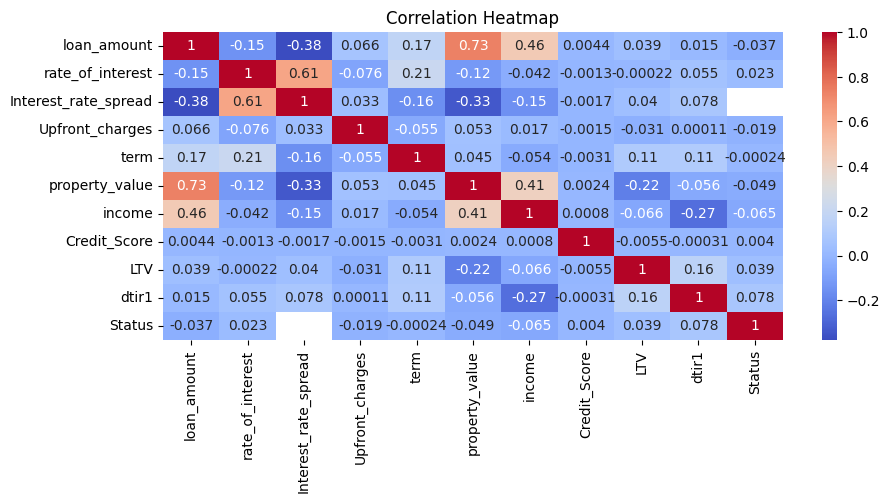

In [59]:
correlation_matrix = data[num_cols_with_target].corr()

# Visualizing correlation heatmap
plt.figure(figsize=(10,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Histogram of numerical features(to show the distribution of features)

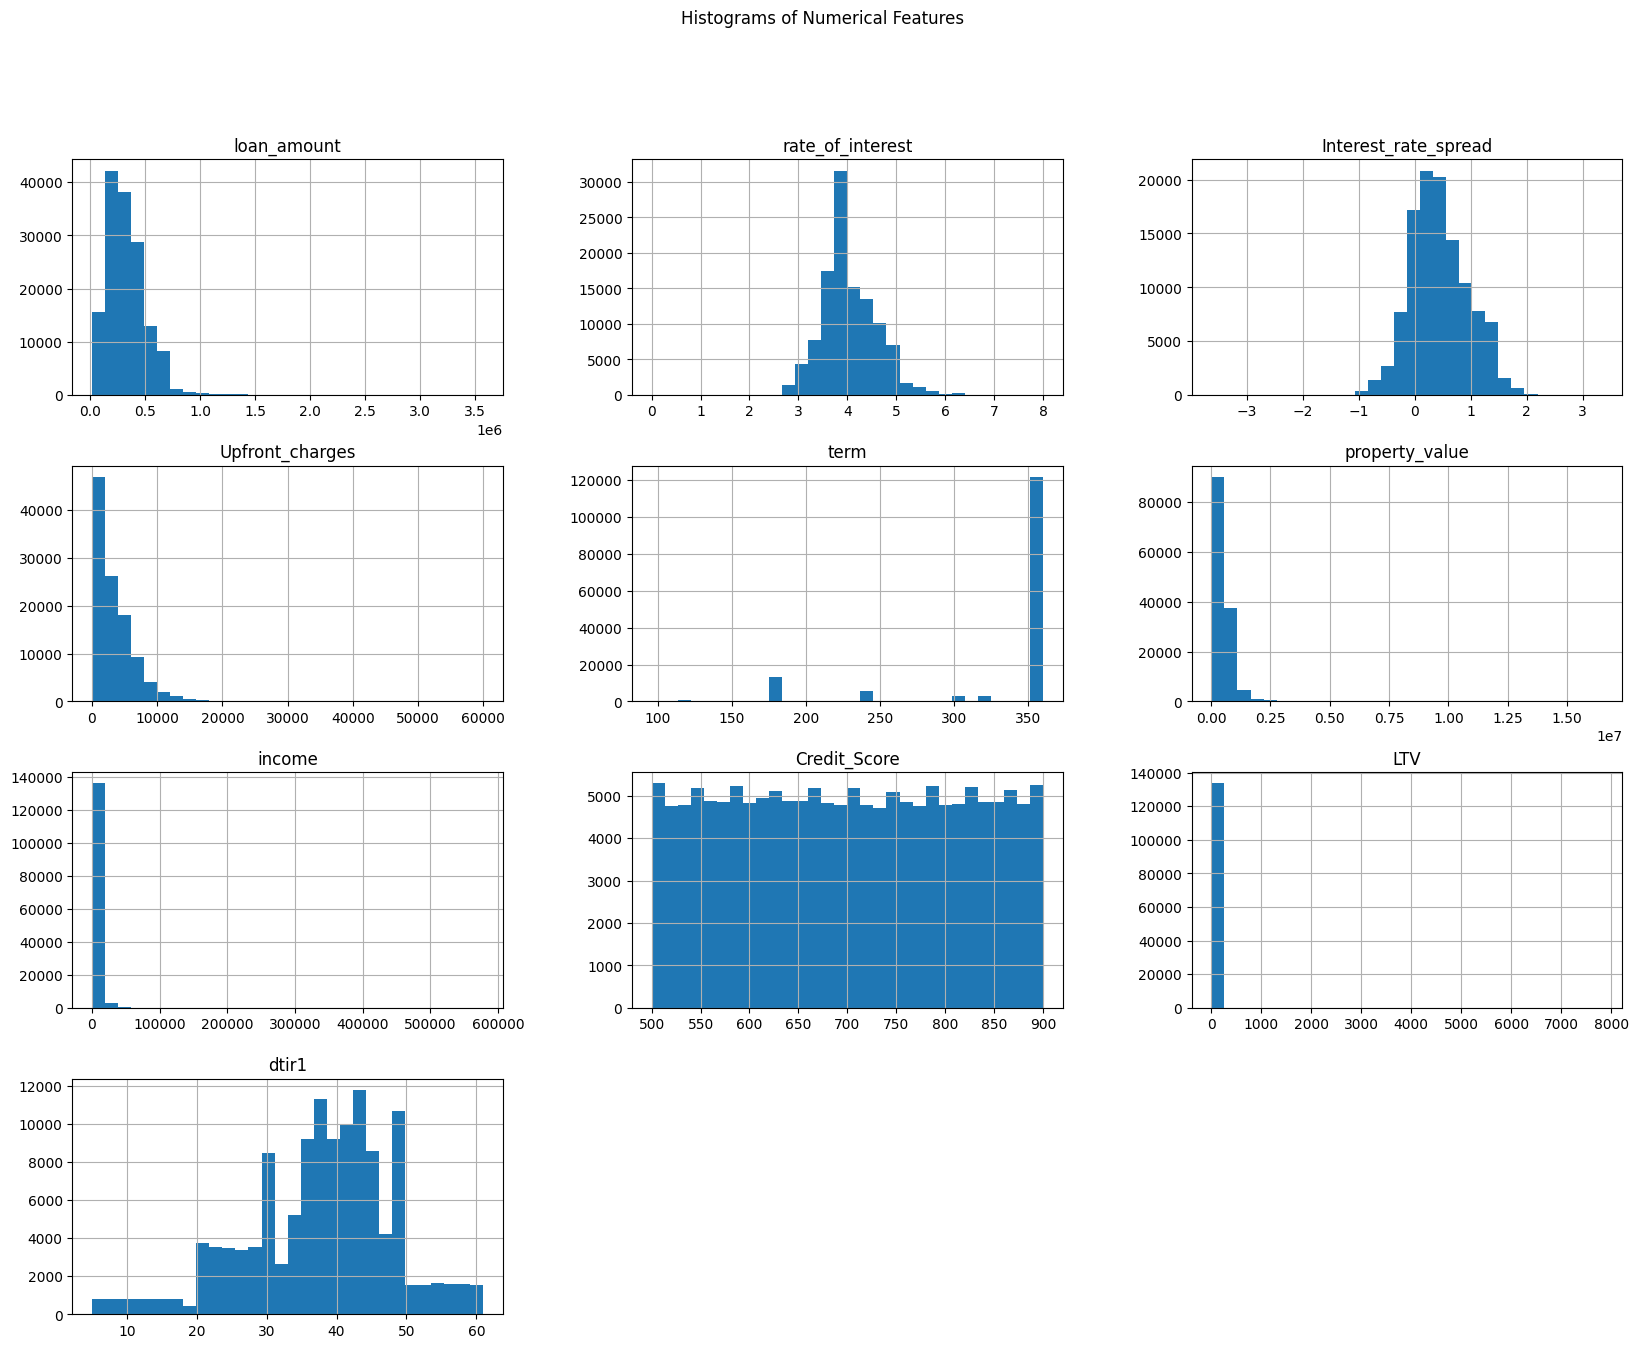

In [60]:
data[num_cols].hist(bins=30, figsize=(20, 15))
plt.suptitle('Histograms of Numerical Features')
plt.show()

Boxplot to understand the skewness potential outliers of the numerical feature

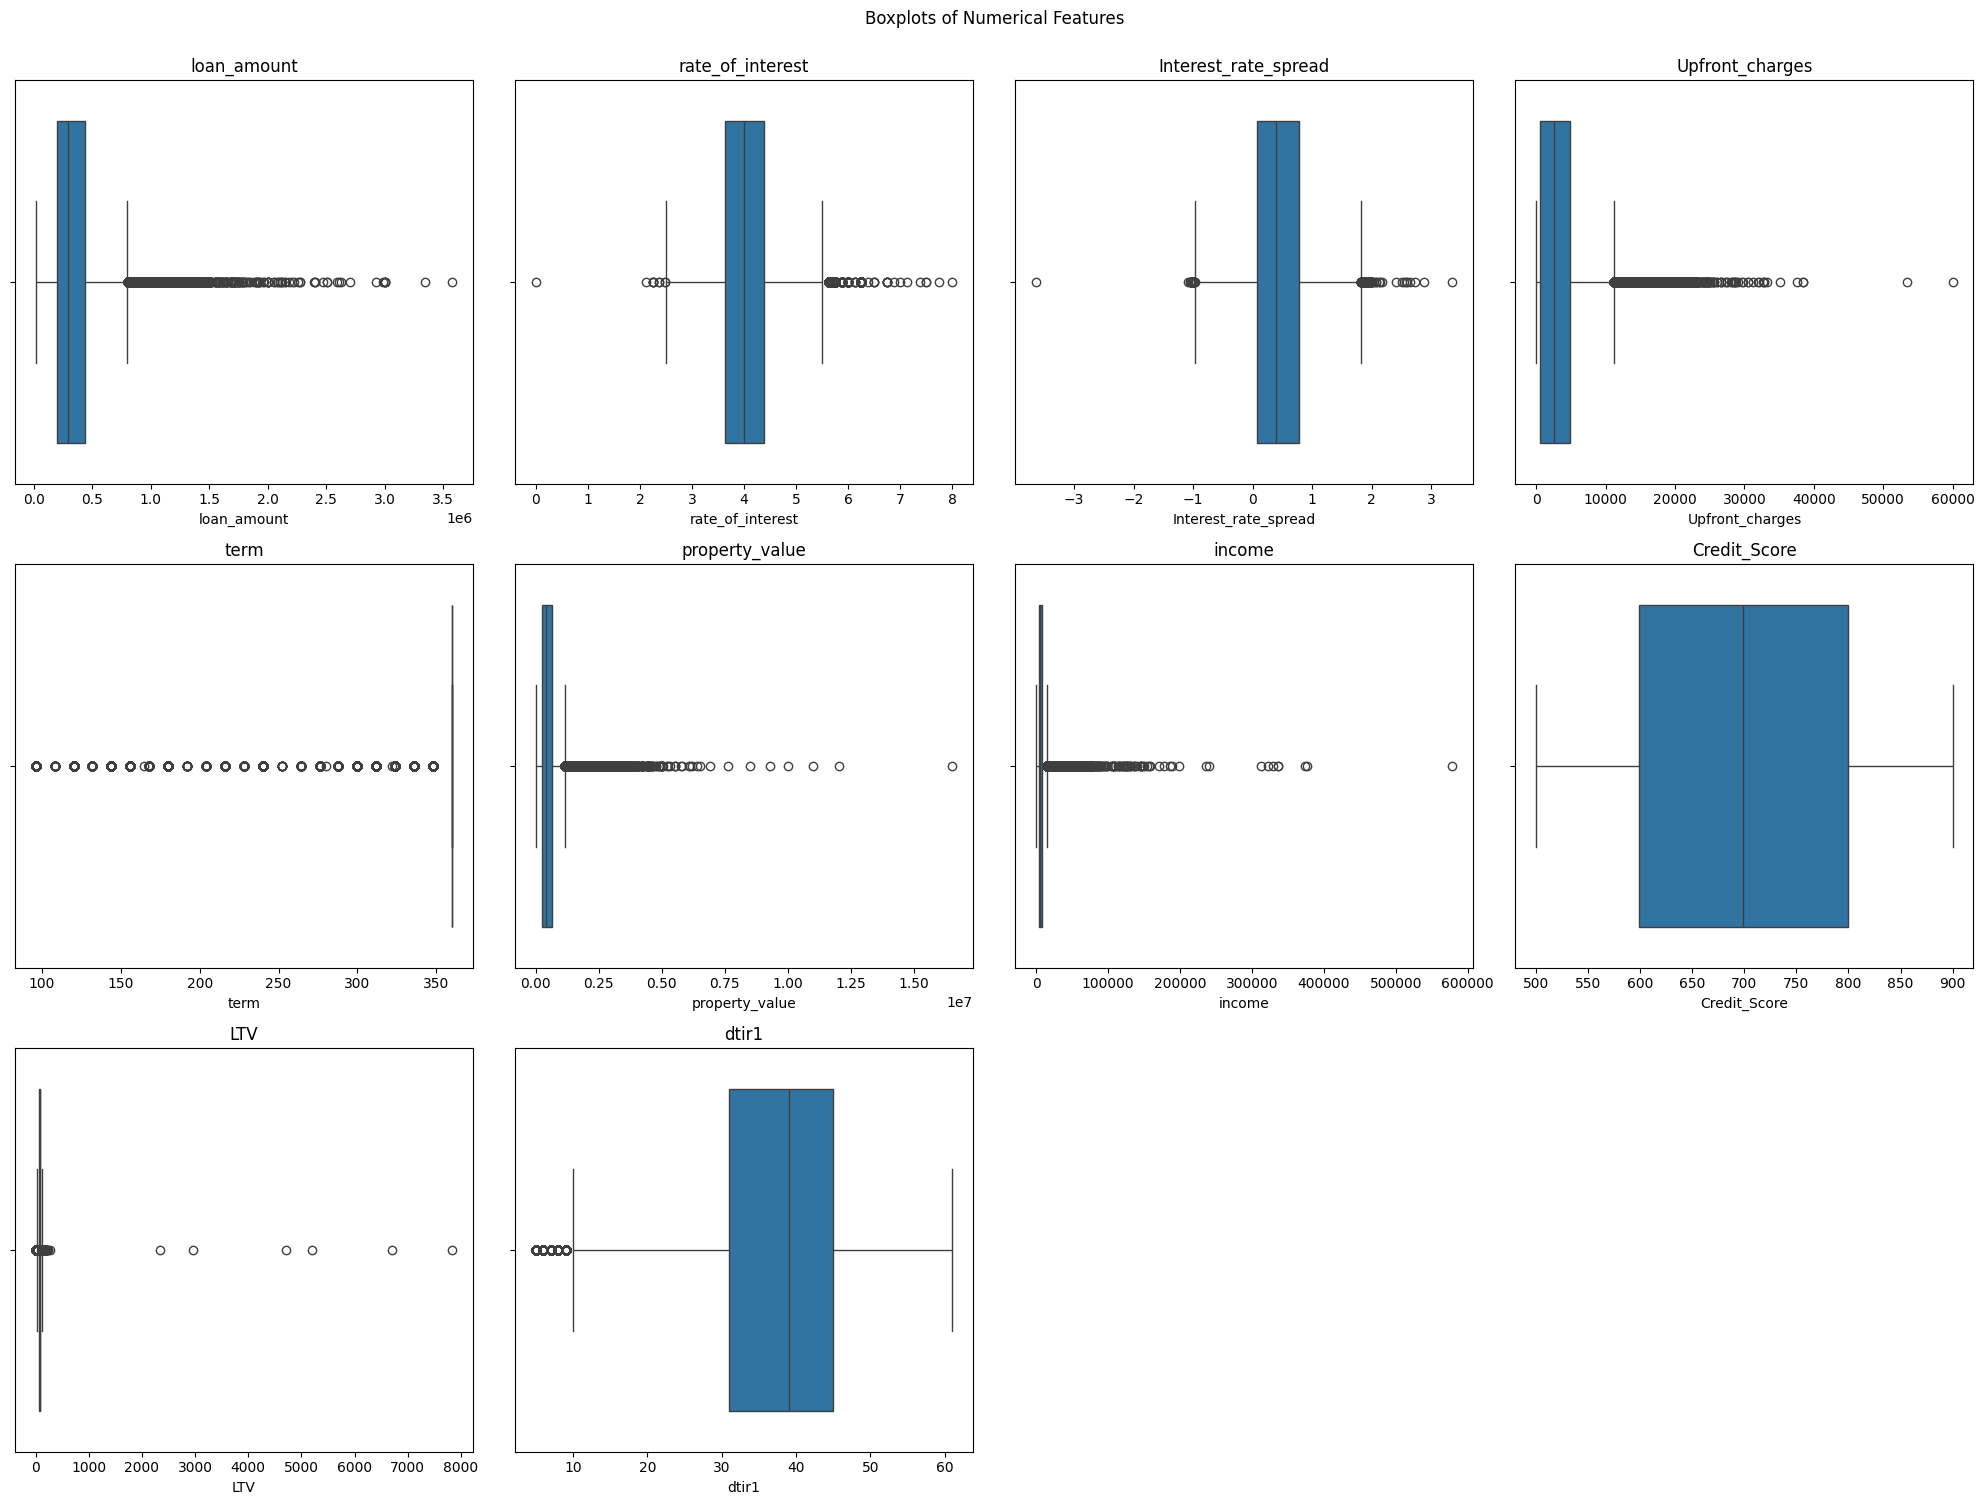

In [61]:
plt.figure(figsize=(20,15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,4, i)
    sns.boxplot(x=data[col])
    plt.title(col)
plt.suptitle('Boxplots of Numerical Features', y = 1)
plt.tight_layout()
plt.show()

In [62]:
data[num_cols].isnull().sum()

loan_amount                 0
rate_of_interest        36439
Interest_rate_spread    36639
Upfront_charges         39642
term                       41
property_value          15098
income                   9150
Credit_Score                0
LTV                     15098
dtir1                   24121
dtype: int64

In [70]:
status_upfront_summary = data.groupby('Status')['property_value'].apply(lambda x: x.isnull().sum())
print(status_upfront_summary)

Status
0        2
1    15096
Name: property_value, dtype: int64


In [68]:
data["income"] = data["income"].fillna(data["income"].median())
#zero_charges = data[data['Upfront_charges'] == 0].shape[0]
#print(zero_charges)

In [69]:
data["income"].corr(data["Status"])

np.float64(-0.06061815355487695)